# Carbon budget outcome — ambition x CCS matrix

The sixteen cells compared against each scenario's own GCAM smelting budget, as cumulative
emissions over time and as 2050 cumulative bars. **Colour is the GCAM ambition scenario**
(SSP-RCP pair); line style is the CCS regime. Each ambition scenario carries its own GCAM demand,
grid and budget, so the budget differs by colour.

Smelter-only: refining is inert to the grid/CCS levers and was not re-run on GCAM demand, so it is
excluded here (it would mix demand bases). Interim stand-in GCAM runs — method validation.

In [1]:
import sys, importlib
sys.path.append("../..")
import common; importlib.reload(common)

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from common import (GRIDS, GRID_LABELS, CCS_ORDER, CCS_LABELS, GRID_COLOURS, run_name,
                    emissions, budget, style, save)

style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Line style carries the CCS regime; colour carries the ambition scenario.
CCS_STYLE = {"none": ":", "low": "-.", "high": "--", "unlimited": "-"}

In [2]:
# Cumulative smelting emissions (Gt) per cell, and each ambition scenario's own budget.
cum_smelting = {}
for grid in GRIDS:
    for ccs in CCS_ORDER:
        n = run_name(grid, ccs)
        cum_smelting[(grid, ccs)] = emissions(n, "smelter").cumsum() / 1000
# CCS regime does not change the budget, so any cell of an ambition gives its budget.
budgets_cum = {grid: budget("smelter", run_name(grid, "none")).cumsum() / 1000 for grid in GRIDS}
for grid in GRIDS:
    print(f"{GRID_LABELS[grid]} smelting budget {budgets_cum[grid].loc[2050]:.2f} Gt")

SSP1-1.9 smelting budget 10.24 Gt
SSP1-2.6 smelting budget 13.03 Gt
SSP2-3.7 smelting budget 17.87 Gt
SSP2-4.5 smelting budget 19.61 Gt


## Cumulative emissions over time

Thin lines are the 16 cells (colour = ambition, style = CCS); thick translucent lines are each ambition scenario's own GCAM budget.

wrote figures/budget_cumulative_over_time.png and .svg


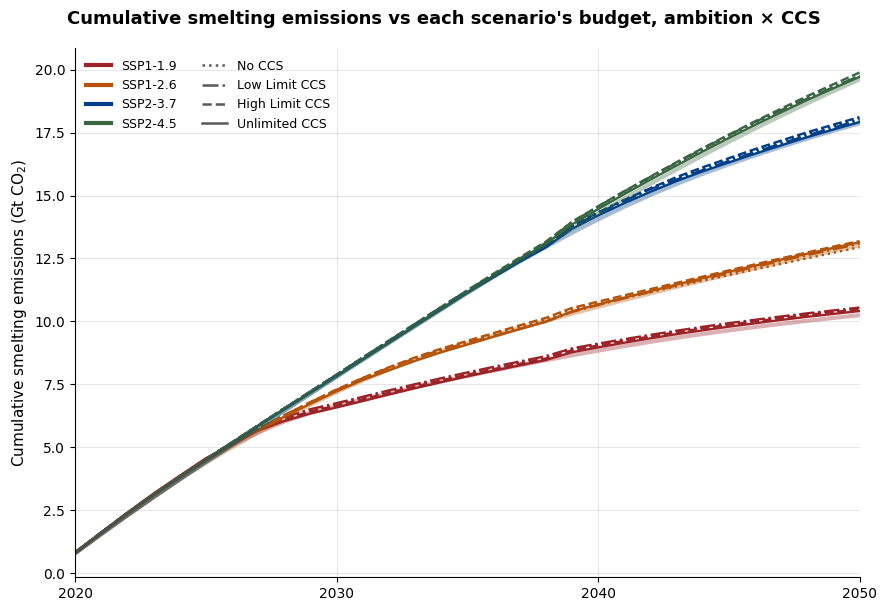

In [3]:
fig, ax = plt.subplots(figsize=(9, 6.2))
for grid in GRIDS:
    for ccs in CCS_ORDER:
        line = cum_smelting[(grid, ccs)]
        ax.plot(line.index, line.values, color=GRID_COLOURS[grid],
                linestyle=CCS_STYLE[ccs], linewidth=1.7)
for grid in GRIDS:                                   # each scenario's own budget
    b = budgets_cum[grid]
    ax.plot(b.index, b.values, color=GRID_COLOURS[grid], linewidth=3.0, alpha=0.35)
ax.set_xlim(2020, 2050); ax.set_xticks(range(2020, 2051, 10))
ax.set_ylabel("Cumulative smelting emissions (Gt CO$_2$)")

grid_handles = [Line2D([0], [0], color=GRID_COLOURS[g], lw=3, label=GRID_LABELS[g]) for g in GRIDS]
ccs_handles = [Line2D([0], [0], color="0.35", lw=1.8, linestyle=CCS_STYLE[c],
               label=CCS_LABELS[c].replace("\n", " ")) for c in CCS_ORDER]
ax.legend(handles=grid_handles + ccs_handles, ncol=2, frameon=False, fontsize=9, loc="upper left")
fig.suptitle("Cumulative smelting emissions vs each scenario's budget, ambition \u00d7 CCS",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "budget_cumulative_over_time")
plt.show()

## 2050 cumulative against budget — bars

Bars are 2050 cumulative smelting emissions (colour = ambition); the black bar in each ambition group is that scenario's GCAM budget.

wrote figures/budget_total_bars.png and .svg


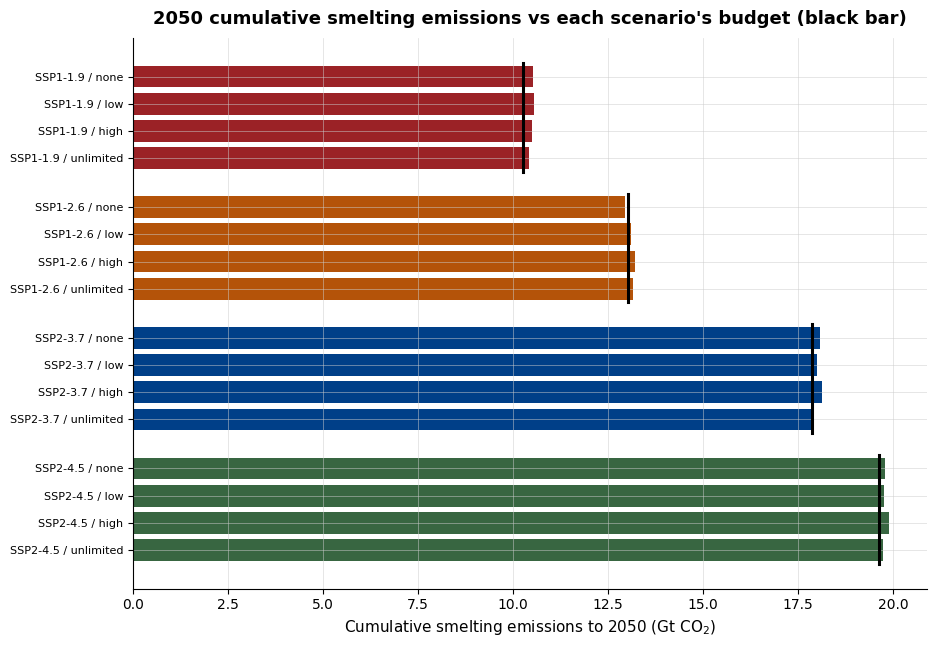

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 6.6))
labels, positions = [], []
y = 0.0
for grid in GRIDS:
    y0 = y
    for ccs in CCS_ORDER:
        val = cum_smelting[(grid, ccs)].loc[2050]
        ax.barh(y, val, color=GRID_COLOURS[grid], height=0.8)
        labels.append(f"{GRID_LABELS[grid]} / {ccs}"); positions.append(y); y += 1
    bud = budgets_cum[grid].loc[2050]
    ax.plot([bud, bud], [y0 - 0.5, y - 0.5], color="black", lw=2.2)     # this scenario's budget
    y += 0.8
ax.set_yticks(positions); ax.set_yticklabels(labels, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("Cumulative smelting emissions to 2050 (Gt CO$_2$)")
ax.set_title("2050 cumulative smelting emissions vs each scenario's budget (black bar)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "budget_total_bars")
plt.show()

## Capture by how the plant got there — newbuild vs retrofit

Power-capture production in 2050, split by whether the capture-equipped plant was a new build
(greenfield or rebuild) or an existing plant retrofitted in place (brownfield renovation). The
retrofit-vs-newbuild share bears on whether greenfield captive fossil+CCS should be allowed at
all (open item O4): a result that leans on newbuild capture in the 2040s is the less credible
one. Two terracotta shades: darker = retrofit, lighter = newbuild.

In [5]:
from pathlib import Path
import glob

def capture_split(grid, ccs):
    """2050 power-capture production (Mt), split into newbuild and retrofit by entry path."""
    n = run_name(grid, ccs)
    path = glob.glob(f"../../runs/{n}/smelter/final/plant_stack_transition_*.csv")[0]
    d = pd.read_csv(path).sort_values(["uuid", "year"])
    # power capture = the power half of "<anode> + <power>" ends with +CCS
    d["pcap"] = d["technology"].str.split(" + ", n=1, regex=False).str[1].fillna("").str.endswith("+CCS")
    cap2050 = set(d[(d["year"] == 2050) & d["pcap"]]["uuid"])
    newbuild = retrofit = 0.0
    for uuid, g in d[d["uuid"].isin(cap2050)].groupby("uuid"):
        first = g[g["pcap"]].iloc[0]                     # year this plant first became capture
        if first["retrofit_status"]:
            retrofit += first["annual_production_volume"]
        else:                                            # greenfield or rebuild
            newbuild += first["annual_production_volume"]
    return newbuild, retrofit

TERRACOTTA_NEW = "#e6a17a"     # lighter: newbuild
TERRACOTTA_RETRO = "#a83e2c"   # darker: retrofit

wrote figures/budget_capture_newbuild_vs_retrofit.png and .svg


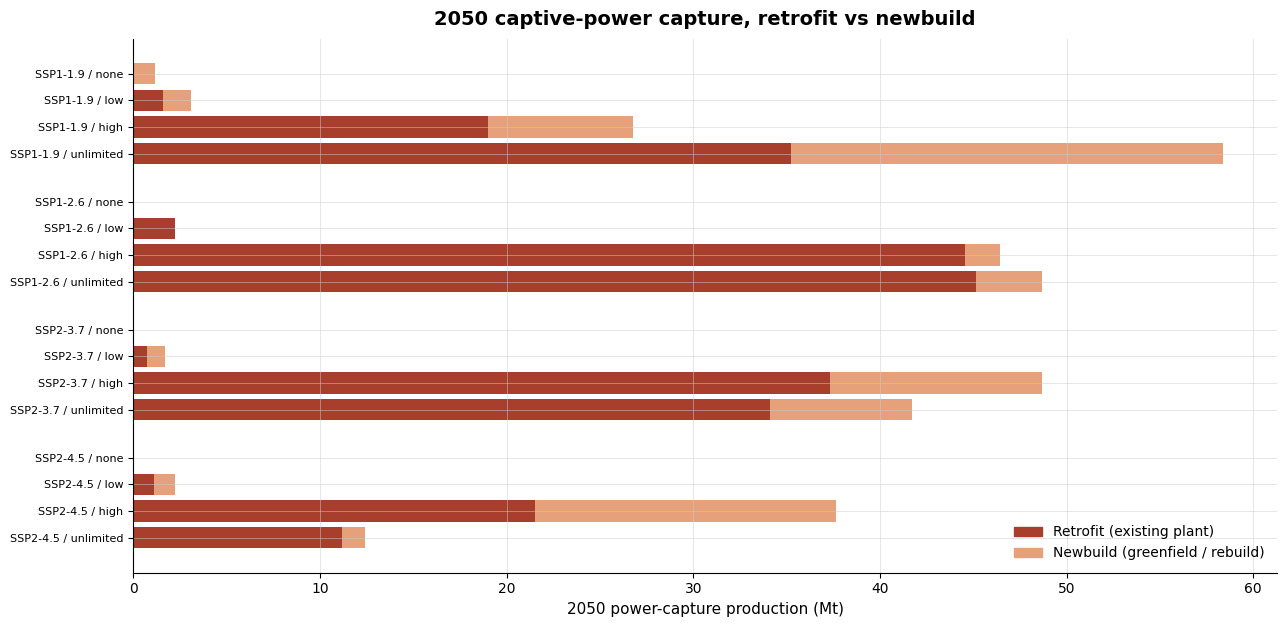

In [6]:
fig, ax = plt.subplots(figsize=(13, 6.4))
labels, positions = [], []
y = 0.0
for grid in GRIDS:
    for ccs in CCS_ORDER:
        nb_mt, rf_mt = capture_split(grid, ccs)
        ax.barh(y, rf_mt, color=TERRACOTTA_RETRO, height=0.8)
        ax.barh(y, nb_mt, left=rf_mt, color=TERRACOTTA_NEW, height=0.8)
        labels.append(f"{GRID_LABELS[grid]} / {ccs}"); positions.append(y); y += 1
    y += 0.8
ax.set_yticks(positions); ax.set_yticklabels(labels, fontsize=8); ax.invert_yaxis()
ax.set_xlabel("2050 power-capture production (Mt)")
ax.set_title("2050 captive-power capture, retrofit vs newbuild", fontsize=14, fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=TERRACOTTA_RETRO, label="Retrofit (existing plant)"),
                   Patch(color=TERRACOTTA_NEW, label="Newbuild (greenfield / rebuild)")],
          frameon=False, fontsize=10, loc="lower right")
fig.tight_layout()
save(fig, "budget_capture_newbuild_vs_retrofit")
plt.show()

In [7]:
# Table form of the same split
rows = []
for grid in GRIDS:
    for ccs in CCS_ORDER:
        nb_mt, rf_mt = capture_split(grid, ccs)
        tot = nb_mt + rf_mt
        rows.append({"Ambition": GRID_LABELS[grid], "CCS regime": CCS_LABELS[ccs].replace("\n", " "),
                     "Retrofit Mt": rf_mt, "Newbuild Mt": nb_mt,
                     "Newbuild share %": (100 * nb_mt / tot) if tot > 0 else 0.0})
pd.DataFrame(rows)

,Ambition,CCS regime,Retrofit Mt,Newbuild Mt,Newbuild share %
0,SSP1-1.9,No CCS,0.00,1.18,100.00
1,SSP1-1.9,Low Limit CCS,1.59,1.53,49.02
2,SSP1-1.9,High Limit CCS,18.99,7.80,29.10
3,SSP1-1.9,Unlimited CCS,35.22,23.14,39.65
4,SSP1-2.6,No CCS,0.00,0.00,0.00
5,SSP1-2.6,Low Limit CCS,2.24,0.00,0.00
6,SSP1-2.6,High Limit CCS,44.56,1.90,4.09
7,SSP1-2.6,Unlimited CCS,45.12,3.57,7.33
8,SSP2-3.7,No CCS,0.00,0.00,0.00
9,SSP2-3.7,Low Limit CCS,0.75,0.95,55.78


## Summary table

In [8]:
rows = []
for grid in GRIDS:
    for ccs in CCS_ORDER:
        s = cum_smelting[(grid, ccs)].loc[2050]
        bud = budgets_cum[grid].loc[2050]
        rows.append({"Ambition": GRID_LABELS[grid], "CCS regime": CCS_LABELS[ccs].replace("\n", " "),
                     "Smelting Gt": s, "vs budget %": 100 * (s / bud - 1)})
pd.DataFrame(rows)

,Ambition,CCS regime,Smelting Gt,vs budget %
0,SSP1-1.9,No CCS,10.52,2.70
1,SSP1-1.9,Low Limit CCS,10.55,2.98
2,SSP1-1.9,High Limit CCS,10.48,2.35
3,SSP1-1.9,Unlimited CCS,10.41,1.63
4,SSP1-2.6,No CCS,12.95,-0.62
5,SSP1-2.6,Low Limit CCS,13.08,0.44
6,SSP1-2.6,High Limit CCS,13.19,1.27
7,SSP1-2.6,Unlimited CCS,13.14,0.90
8,SSP2-3.7,No CCS,18.07,1.11
9,SSP2-3.7,Low Limit CCS,18.00,0.71
